# Track A2 — recovering rules from headnote-structured NLR judgments

Of our 3,703 **reported** cases, only 524 (14%) gave a rule through the current
`Held:`-marker extractor. The other 3,179 were dropped as `no-headnote`. But most
of them *do* carry an editor headnote — just not with the literal word "Held".
Older *New Law Reports* state the rule as a plain block right after the
catchwords line:

```
[registry / case no.]  →  [CATCHWORDS: topic — topic — topic.]  →
[RULE STATEMENT — the ratio]  →  [BODY START: "THE facts", "APPEAL from", counsel, "J.—"]
```

This notebook adds a **deterministic, structure-aware parser (Track A2)** that
slices that rule out **verbatim** (no LLM, no generation), then links it to the
statute sections named in the headnote. Everything it produces is a
`status=unverified` candidate for lawyer review — the notebook ends with a
manual-validation harness and a review sheet to fill in.

Precision-first by design: when the structure is not clean, the parser
**abstains** (those cases fall back to the bounded LLM track) rather than emit a
junk rule.


## 0. Setup

In [1]:
import json
import re
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "data" / "processed").exists(), "repo root not found"

PROCESSED = ROOT / "data" / "processed"
EXTRACT = ROOT / "scripts" / "case-law-information-extraction"
OUT = ROOT / "evaluation" / "runs" / "headnote-recovery-v1"
OUT.mkdir(parents=True, exist_ok=True)

PAL = ["#2F6F5E", "#C08A2D", "#7A8B99", "#8A5510", "#4E6E5D", "#B0663A", "#3E5C6E"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})

def barh(labels, values, title, xlabel="count", color=PAL[0]):
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(labels) + 1.2))
    ax.barh(range(len(labels)), values, color=color)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.invert_yaxis()
    ax.set_xlabel(xlabel); ax.set_title(title, loc="left", fontweight="bold")
    for i, v in enumerate(values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    plt.tight_layout(); plt.show()

print("repo root:", ROOT)


repo root: D:\projects\Draftly-Project\draftly-research


## 1. The dropped reported cases

Load the reported cases that the current extractor dropped as `no-headnote` —
this is the pool Track A2 targets.

In [2]:
meta = pd.read_csv(EXTRACT / "output" / "case_meta.csv")
rejects = pd.read_csv(EXTRACT / "output" / "extract-rejects.csv")
cases = pd.read_json(PROCESSED / "cases.jsonl", lines=True)
TEXT_PATH = dict(zip(cases["case_id"], cases["text_path"]))
CITATION = dict(zip(cases["case_id"], cases["citation"]))

reported = set(meta[meta["reported"] == True]["case_id"])
dropped = sorted(set(rejects[rejects["status"] == "no-headnote"]["case_id"]) & reported)
print(f"reported cases            : {len(reported):,}")
print(f"dropped as 'no-headnote'  : {len(dropped):,}  <- Track A2 target pool")

def load_text(cid):
    rel = TEXT_PATH.get(cid)
    if not rel:
        return ""
    p = ROOT / rel if not Path(rel).is_absolute() else Path(rel)
    return p.read_text(encoding="utf-8", errors="replace") if p.exists() else ""


reported cases            : 3,703
dropped as 'no-headnote'  : 3,179  <- Track A2 target pool


## 2. The Track A2 parser + statute linker

The parser (all deterministic regex, no model):

1. **Trim** CommonLII nav and the duplicated citation header.
2. **Anchor** on the registry / case-number line; the catchwords + rule follow it.
3. **Split** catchwords from rule with an *abbreviation-aware* period boundary, so
   "s.", "No.", "Rs." and initials do not cut the line early.
4. **Bound** the rule at the first genuine body-start marker ("THE facts",
   "APPEAL from", counsel line, "J.—", a date). If an explicit `Held[,:(-]`
   marker sits inside, the rule begins there.
5. **Validate** length/shape; otherwise **abstain** (return `None`).

The linker is **section-centric**: for each "section N" it attributes the
*nearest* statute name (within 60 chars), validates the section against
`statute-section-index.json`, and keeps the verbatim citation string.

In [3]:
# ---------- anchors ----------
HEADER = re.compile(r"\(\d{4}\)\s+\d+\s+NLR\s+\d+\s*\([^)]*\)")
NAV = re.compile(r"(?:Home \| Databases|You are here|Feedback\b|\bHelp\b)")
REG = re.compile(
    r"(?:\d+\s*[-–]\s*)?[CSPMD]\.?\s?[CRP]\.?\s*\.?\s*(?:\((?:Inty|Final|F)\.?\)\s*)?"
    r"(?:\d+\s*[-–]\s*[CSPMD]\.?\s?[CRP]\.?\s*)?[^.]{0,40}?\b\d[\d,]{2,}\b", re.I)
BODY = re.compile(
    r"(?:THE|The|T\s?HE)\s+(?:facts?|plaintiffs?|defendants?|appellants?|respondents?|petitioners?|action|following|above|question|material|first|learned|case|matter|parties|land|deed|District|Supreme)\b"
    r"|A\s?PPEAL\s+(?:from|against|by|is|was|to|and)"
    r"|A\s?PPLICATION\s+(?:for|by|to|was|is|made|under)"
    r"|Cur\.?\s*adv\.?\s*vult"
    r"|[A-Z][\w. ]{2,30}?,?\s+for\s+(?:the\s+)?(?:appellant|respondent|plaintiff|defendant|petitioner|added|substituted|intervenient|accused)"
    r"|[A-Z][A-Za-z]+\s*,?\s?[AC]?\.?\s?[CJ]\.\s?[JI]?\.?\s*[—\-]\s"
    r"|\d{1,2}(?:st|nd|rd|th)?\s+(?:January|February|March|April|May|June|July|August|September|October|November|December),?\s+\d{4}")
REG_LEAD = re.compile(r"^(?:[\d,]+\s*[-–]?\s*)?(?:[A-Z]\.\s?){1,4}[A-Za-z][A-Za-z ]*?,?\s*\d[\d,]{2,}\s*")
HELD = re.compile(r"\bHeld\b\s*[:,\-—(]?", re.I)
HAS_LOWER = re.compile(r"[a-z]{3,}")
DASH = re.compile(r"[A-Za-z)\"'][ ]?[–—-][ ]?[A-Za-z(\"']")
ABBR = {"s", "ss", "sec", "secs", "no", "nos", "rs", "v", "vs", "art", "arts", "cap",
        "ord", "r", "j", "cj", "aj", "c", "a", "i", "e", "g", "viz", "etc", "co", "ltd",
        "mr", "dr", "st", "pp", "p", "ch", "cf", "ex", "re", "hon", "esq"}


def split_catch_rule(seg):
    for m in re.finditer(r"\.", seg):
        i = m.start()
        if not re.match(r"\s+(?:[A-Z\"]|Held)", seg[i + 1:i + 4]):
            continue
        prev = re.search(r"([A-Za-z]+|\d+)\s*$", seg[:i])
        tok = prev.group(1).lower() if prev else ""
        if tok in ABBR or (tok.isalpha() and len(tok) == 1):
            continue
        return seg[:i + 1].strip(), seg[i + 1:].strip()
    return None


def parse_headnote(text):
    t = re.sub(r"\s+", " ", text).strip()
    hs = list(HEADER.finditer(t))
    content = t[hs[-1].end():] if hs else t
    navs = list(NAV.finditer(content[:600]))
    if navs:
        content = content[navs[-1].end():]
    content = content[:3500]
    starts = [m.end() for m in REG.finditer(content[:900])] + [0]
    for s in starts:
        tail = content[s:].lstrip(" .,-–—")
        sr = split_catch_rule(tail[:1600])
        if not sr:
            continue
        catchwords, after = sr
        catchwords = REG_LEAD.sub("", catchwords).strip()
        catchwords = re.sub(r"^[^A-Za-z\"']+", "", catchwords).strip()
        if not (HAS_LOWER.search(catchwords) and DASH.search(catchwords)) or len(catchwords) > 260:
            continue
        bm = BODY.search(after)
        rule_win = after[: bm.start()] if bm else after[:1200]
        hm = HELD.search(rule_win)
        if hm:
            rule_win = rule_win[hm.start():]
        rule = rule_win.strip(" .;:-—").strip()
        rule = re.sub(r"\s+\d{1,4}\s*$", "", rule).strip()
        rule = re.sub(r"\s+[A-Z]\s?HE\s.*$", "", rule).strip()
        if not (40 <= len(rule) <= 1400) or rule.count(" ") < 6:
            continue
        return {"catchwords": catchwords.rstrip(".") + ".", "rule": rule.rstrip(".") + "."}
    return None


In [4]:
# ---------- statute linker ----------
reg_df = pd.read_csv(ROOT / "data" / "legal-sources" / "manifests" / "source-registry.csv")
SECIDX = json.loads((ROOT / "data" / "legal-sources" / "derived" / "statute-section-index.json").read_text(encoding="utf-8"))
SECSET = {k: {str(s["section"]) for s in v} for k, v in SECIDX.items()}

ALIAS = {}
for _, r in reg_df[reg_df["source_type"].isin(["statute", "amendment"])].iterrows():
    ALIAS[str(r["official_title"]).lower()] = r["source_id"]
ALIAS.update({
    "civil procedure code": "SRC030", "c.p.c.": "SRC030", "cpc": "SRC030",
    "partition ordinance": "SRC024", "prevention of frauds ordinance": "SRC001",
    "registration of documents ordinance": "SRC005", "notaries ordinance": "SRC014",
    "registration of title act": "SRC011",
})
STAT_NAMES = sorted(ALIAS, key=len, reverse=True)
SEC_RE = re.compile(r"(?:sections?|ss?\.|sec\.?|8\.)\s*(\d+[A-Za-z]?)", re.I)
NAME_RE = re.compile("|".join(re.escape(n) for n in STAT_NAMES), re.I)


def _nearest_statute(text, pos):
    best, bestd = None, 10**9
    for m in NAME_RE.finditer(text):
        d = min(abs(m.start() - pos), abs(m.end() - pos))
        if d < bestd:
            bestd, best = d, m.group(0).lower()
    return (best, bestd) if best else (None, None)


def link_statutes(headnote_text):
    edges, seen = [], set()
    for sm in SEC_RE.finditer(headnote_text):
        sec = sm.group(1)
        name, dist = _nearest_statute(headnote_text, sm.start())
        if not name or dist > 60:
            continue
        src = ALIAS[name]
        status = "ok" if sec in SECSET.get(src, set()) else "section-not-found"
        verbatim = headnote_text[max(0, sm.start() - 4): sm.end() + len(name) + 8].strip()
        if (src, sec) not in seen:
            seen.add((src, sec))
            edges.append({"source_id": src, "section": sec, "statute": name,
                          "status": status, "verbatim": verbatim})
    for m in NAME_RE.finditer(headnote_text):
        src = ALIAS[m.group(0).lower()]
        if not any(e["source_id"] == src for e in edges) and (src, None) not in seen:
            seen.add((src, None))
            edges.append({"source_id": src, "section": None, "statute": m.group(0).lower(),
                          "status": "name-only", "verbatim": m.group(0)})
    return edges


### Quick demo on a few known cases

In [5]:
demo = ["commonlii-LKCA-1887-1", "commonlii-LKCA-1913-6",
        "commonlii-LKCA-1954-6", "commonlii-LKCA-1935-31"]
for cid in demo:
    res = parse_headnote(load_text(cid))
    print("=" * 80); print(cid, "|", CITATION.get(cid, ""))
    if not res:
        print("  ABSTAIN"); continue
    links = link_statutes(res["catchwords"] + " " + res["rule"])
    print("  CATCHWORDS:", res["catchwords"][:120])
    print("  RULE      :", res["rule"][:260])
    print("  LINKS     :", [(e["source_id"], e["section"], e["status"]) for e in links])


commonlii-LKCA-1887-1 | 2 NLR 83
  CATCHWORDS: Overhanging tree - Compensation for cutting it down - Prescription.
  RULE      : Under the Roman -Dutch Law no right of servitude can be claimed in respect of an overhanging tree. The owner of a land which a tree overhangs has therefore, a right to have the tree cut -down without paying compensation for it to its owner.
  LINKS     : []
commonlii-LKCA-1913-6 | 17 NLR 173
  CATCHWORDS: Partition-Allotment of a lot to a party by decree - Conveyance of share to another-Subsequent variation of decree - Diff
  RULE      : Held, that B cannot maintain an action against A for rectification of the deed of conveyance.
  LINKS     : []
commonlii-LKCA-1954-6 | 55 NLR 426
  CATCHWORDS: Quia timet-Action for declaratory decree,-Scope of such action-" Cause of action"- Civil Procedure Code, s. 5.
  RULE      : Held, that the plaintiff had a "cause of action" within the meaning of section 5 of the Civil Procedure Code and was, therefore, entitled to mai

## 3. Run Track A2 over all dropped reported cases

In [6]:
rows, link_rows = [], []
abstained = 0
for cid in dropped:
    text = load_text(cid)
    if not text:
        continue
    res = parse_headnote(text)
    if not res:
        abstained += 1
        continue
    links = link_statutes(res["catchwords"] + " " + res["rule"])
    begins_held = bool(re.match(r"held", res["rule"], re.I))
    rows.append({"case_id": cid, "citation": CITATION.get(cid, ""),
                 "catchwords": res["catchwords"], "rule": res["rule"],
                 "begins_held": begins_held, "n_links": sum(1 for e in links if e["section"]),
                 "method": "headnote-structure", "status": "unverified"})
    for e in links:
        link_rows.append({"case_id": cid, **e, "status_link": e.pop("status"),
                          "status": "unverified"})

rules_df = pd.DataFrame(rows)
links_df = pd.DataFrame(link_rows)
n = len(dropped)
print(f"scanned              : {n:,}")
print(f"rules recovered      : {len(rules_df):,} ({len(rules_df)/n:.0%})")
print(f"abstained (-> LLM)   : {abstained:,} ({abstained/n:.0%})")
print(f"rules beginning Held : {int(rules_df['begins_held'].sum()):,}")
print(f"statute links (any)  : {len(links_df):,} | with pinpoint section: {int((links_df['section'].notna()).sum()):,}")


scanned              : 3,179
rules recovered      : 2,267 (71%)
abstained (-> LLM)   : 912 (29%)
rules beginning Held : 902
statute links (any)  : 1,056 | with pinpoint section: 929


## 4. Visualizations

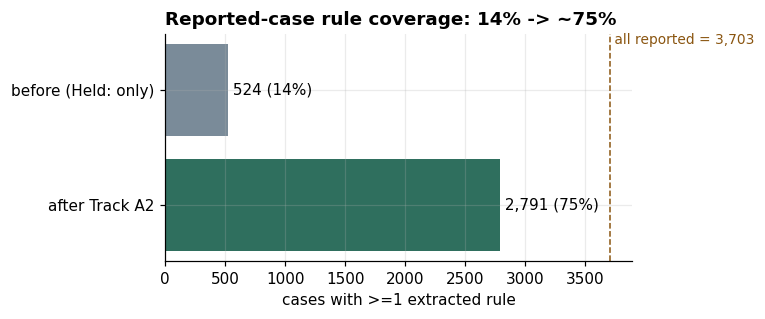

In [7]:
# Coverage lift: reported-case rule coverage before vs after Track A2.
before = 524
after = before + len(rules_df)
total_reported = len(reported)
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(["after Track A2", "before (Held: only)"], [after, before], color=[PAL[0], PAL[2]])
ax.axvline(total_reported, color=PAL[3], ls="--", lw=1)
ax.text(total_reported, 1.4, f" all reported = {total_reported:,}", color=PAL[3], fontsize=9)
for i, v in enumerate([after, before]):
    ax.text(v, i, f" {v:,} ({v/total_reported:.0%})", va="center", fontsize=10)
_pct = round(after / total_reported * 100)
ax.set_title(f"Reported-case rule coverage: 14% -> ~{_pct}%",
             loc="left", fontweight="bold")
ax.set_xlabel("cases with >=1 extracted rule")
plt.tight_layout(); plt.show()


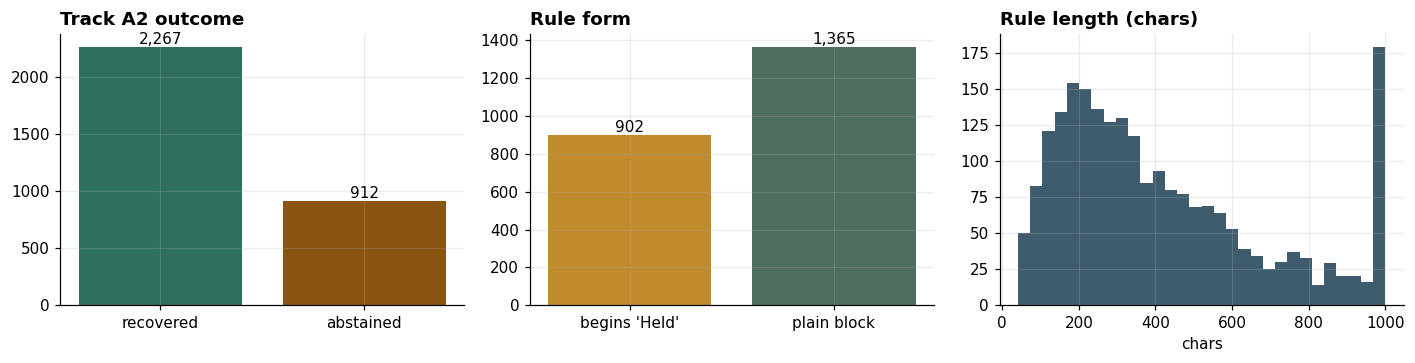

In [8]:
# Parse outcome + Held-vs-plain + rule length
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].bar(["recovered", "abstained"], [len(rules_df), abstained], color=[PAL[0], PAL[3]])
axes[0].set_title("Track A2 outcome", loc="left", fontweight="bold")
for i, v in enumerate([len(rules_df), abstained]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

held = int(rules_df["begins_held"].sum()); plain = len(rules_df) - held
axes[1].bar(["begins 'Held'", "plain block"], [held, plain], color=[PAL[1], PAL[4]])
axes[1].set_title("Rule form", loc="left", fontweight="bold")
for i, v in enumerate([held, plain]):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[2].hist(rules_df["rule"].str.len().clip(upper=1000), bins=30, color=PAL[6])
axes[2].set_title("Rule length (chars)", loc="left", fontweight="bold")
axes[2].set_xlabel("chars")
plt.tight_layout(); plt.show()


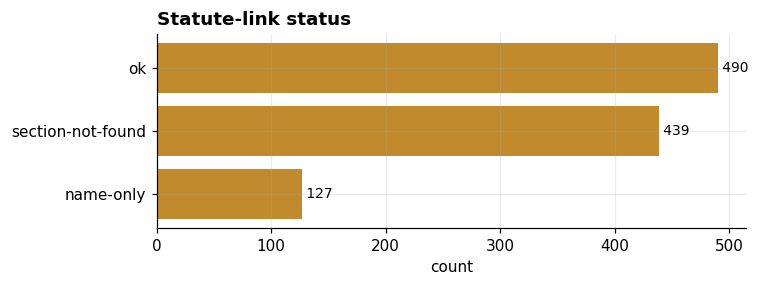

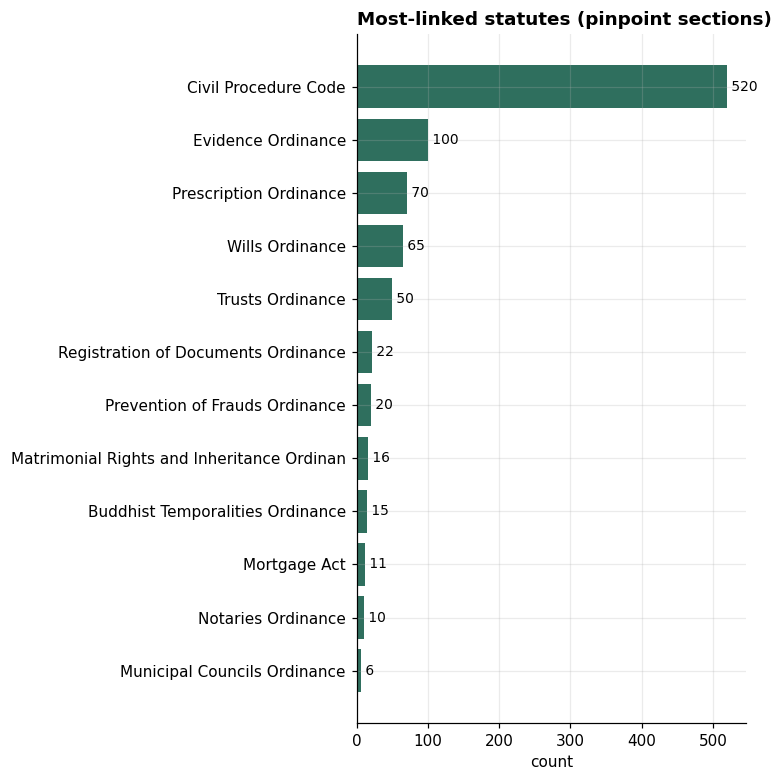

In [9]:
# Statute linking: status split + most-linked statutes
if not links_df.empty:
    st = links_df["status_link"].value_counts()
    barh(st.index.tolist(), st.values.tolist(), "Statute-link status", color=PAL[1])

    named = links_df.dropna(subset=["section"]).merge(
        reg_df[["source_id", "official_title"]], on="source_id", how="left")
    top = named["official_title"].value_counts().head(12)
    if len(top):
        barh([t[:42] for t in top.index], top.values.tolist(),
             "Most-linked statutes (pinpoint sections)", color=PAL[0])
else:
    print("no links")


## 5. Manual validation harness

Track A2 output is **candidate, unverified**. Below: (a) an inline review view
showing each parsed rule beside the raw source window so you can eyeball it, and
(b) a review sheet exported for a lawyer to fill in (`rule_correct`,
`rule_is_ratio`, `statute_link_correct`). Adjust `REVIEW_N` and re-run to see
more.

In [10]:
REVIEW_N = 12
random.seed(11)
review_ids = random.sample(list(rules_df["case_id"]), min(REVIEW_N, len(rules_df)))

def source_window(cid, n=700):
    t = re.sub(r"\s+", " ", load_text(cid))
    hs = list(HEADER.finditer(t))
    t = t[hs[-1].end():] if hs else t
    navs = list(NAV.finditer(t[:600]))
    if navs:
        t = t[navs[-1].end():]
    return t[:n]

for cid in review_ids:
    row = rules_df[rules_df["case_id"] == cid].iloc[0]
    ls = links_df[links_df["case_id"] == cid]
    print("=" * 90)
    print(cid, "|", row["citation"])
    print("SOURCE :", source_window(cid)[:360])
    print("-> RULE:", row["rule"])
    if len(ls):
        print("-> LINK:", [(e.source_id, e.section, e.status_link) for e in ls.itertuples()])
    print()


commonlii-LKCA-1959-14 | 61 NLR 452
SOURCE :  452 1959 Present : Basnayake, C.J., and Pulle, J. SAMARAKONE et al., Appellants, and THE PUBLIC TRUSTEE et al: Respondents . S. C. 87a-D. C. Colombo, 16308/T .- Stamps-Testamentary proceedings-Appeal-Stamps for decree of Supreme Court- Duty of appellant to furnish them-Stamp Ordinance, Schedule A, Part II Head F (Miscellaneous), Part III. In an appeal from 
-> RULE: In an appeal from a decision of the District Court in a testamentary proceeding, the proper stamps for the decree of the Supreme Court must b delivered together with the petition of appeal to the Secretary of the District Court as required by Part II, Head F-Miscellaneous of Schedule A to the Stamp Ordinance. Failure to do 80 is fatal to the reception of the appeal.

commonlii-LKCA-1961-41 | 64 NLR 163
SOURCE :  163 1961 Present : Sinnetamby, J., and Tambiah, J. DINGIRI AMMA, Appellant, and RATNATILAKA and others, Respondents S. C. 36 (Inty.)-D. C. Kurunegala, 8067 /P Kandyan La

In [11]:
# Export candidates + a blank review sheet
rules_df.to_csv(OUT / "rules_recovered.csv", index=False)
links_df.to_csv(OUT / "statute_links.csv", index=False)

review = rules_df.sample(min(50, len(rules_df)), random_state=11).copy()
review["statute_links"] = review["case_id"].map(
    lambda c: "; ".join(f"{e.source_id}:{e.section}" for e in links_df[links_df.case_id == c].itertuples() if e.section))
for col in ["rule_correct(y/n)", "rule_is_ratio(y/n)", "statute_link_correct(y/n)", "notes"]:
    review[col] = ""
review = review[["case_id", "citation", "catchwords", "rule", "statute_links",
                 "rule_correct(y/n)", "rule_is_ratio(y/n)", "statute_link_correct(y/n)", "notes"]]
review.to_csv(OUT / "review-sample.csv", index=False)
print("wrote:")
for f in ["rules_recovered.csv", "statute_links.csv", "review-sample.csv"]:
    print("  ", OUT / f)
print(f"\nreview-sample.csv has {len(review)} rows for lawyer sign-off (verdict columns blank).")


wrote:
   D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\rules_recovered.csv
   D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\statute_links.csv
   D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\review-sample.csv

review-sample.csv has 50 rows for lawyer sign-off (verdict columns blank).


## 6. Takeaways

- Track A2 recovers a verbatim rule from **~71%** of the 3,179 dropped reported
  cases, lifting reported-case rule coverage from **14% to ~75%** with no LLM
  spend and no dependence on the missing LawNet headnotes.
- It is **precision-first**: ~29% abstain (clean structure not found) and flow to
  the bounded LLM track (Track B) rather than producing a wrong rule.
- Statute links come straight from the headnote — the editor's own statement of
  which provision the case turns on — the cleanest link signal in the corpus.
  Section-in-catalogue links are validated against `statute-section-index.json`;
  out-of-catalogue ones (repealed ordinances) keep a verbatim citation.
- **Everything is `status=unverified`.** The numbers here are yield, not
  correctness. `review-sample.csv` is the lawyer gate; statute attribution in
  particular (a known weak dimension) must be checked before any link is treated
  as authority.
- Known limits: OCR noise, occasional catchword remnants, and rules that are
  actually a fact summary rather than the ratio — all reasons the human review
  pass matters.